# Model Training — Blast Damage Classification

Goal: predict `damage_category` (none / minor / moderate / severe / collapse)
from blast parameters and structure type.

Models compared:
1. Random Forest (baseline, interpretable, handles imbalance reasonably)
2. XGBoost (usually stronger on tabular data)
3. A small feed-forward neural net (MLPClassifier) for comparison

We'll use stratified splits and look at per-class precision/recall/F1 given
the class imbalance seen in the EDA notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import xgboost as xgb

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/blast_damage_dataset.csv")
df.head()

,charge_weight_kg,standoff_distance_m,scaled_distance_Z,structure_type,quality_factor,peak_overpressure_kpa,impulse_kpa_ms,damage_category
0,306.765,10.230,1.5168,masonry_wall,1.113,516.217,57.764,severe
1,275.830,64.381,9.8903,steel_frame,0.998,21.907,12.420,none
2,1089.515,30.308,2.9454,masonry_wall,1.056,162.273,55.001,severe
3,0.849,80.242,84.7467,steel_frame,0.994,7.476,0.500,none
4,1568.493,113.527,9.7710,rc_wall,0.958,24.923,21.540,none


## 1. Feature engineering

In [2]:
damage_order = ["none", "minor", "moderate", "severe", "collapse"]

df_model = df.copy()

# Log-transform right-skewed numeric features (per EDA notebook findings)
for col in ["charge_weight_kg", "standoff_distance_m", "peak_overpressure_kpa", "impulse_kpa_ms"]:
    df_model[f"log_{col}"] = np.log1p(df_model[col])

# One-hot encode structure_type
df_model = pd.get_dummies(df_model, columns=["structure_type"], prefix="struct")

feature_cols = [
    "log_charge_weight_kg", "log_standoff_distance_m", "scaled_distance_Z",
    "log_peak_overpressure_kpa", "log_impulse_kpa_ms", "quality_factor",
] + [c for c in df_model.columns if c.startswith("struct_")]

X = df_model[feature_cols]

label_encoder = LabelEncoder()
label_encoder.fit(damage_order)  # fix class order explicitly
y = label_encoder.transform(df_model["damage_category"])

feature_cols

['log_charge_weight_kg',
 'log_standoff_distance_m',
 'scaled_distance_Z',
 'log_peak_overpressure_kpa',
 'log_impulse_kpa_ms',
 'quality_factor',
 'struct_glazing_window',
 'struct_masonry_wall',
 'struct_rc_wall',
 'struct_steel_frame']

## 2. Train / test split (stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
pd.Series(y_train).value_counts().sort_index()

Train shape: (4800, 10)  Test shape: (1200, 10)


0    1157
1     411
2     346
3    2606
4     280
Name: count, dtype: int64

## 3. Model 1 — Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, rf_preds))
print("Random Forest macro-F1:", f1_score(y_test, rf_preds, average="macro"))
print()
print(classification_report(y_test, rf_preds, target_names=damage_order))

Random Forest accuracy: 0.9516666666666667
Random Forest macro-F1: 0.8913070099558599

              precision    recall  f1-score   support

        none       0.97      0.98      0.97       290
       minor       0.86      0.82      0.84       103
    moderate       0.84      0.85      0.84        86
      severe       0.98      0.99      0.99       651
    collapse       0.85      0.79      0.81        70

    accuracy                           0.95      1200
   macro avg       0.90      0.88      0.89      1200
weighted avg       0.95      0.95      0.95      1200



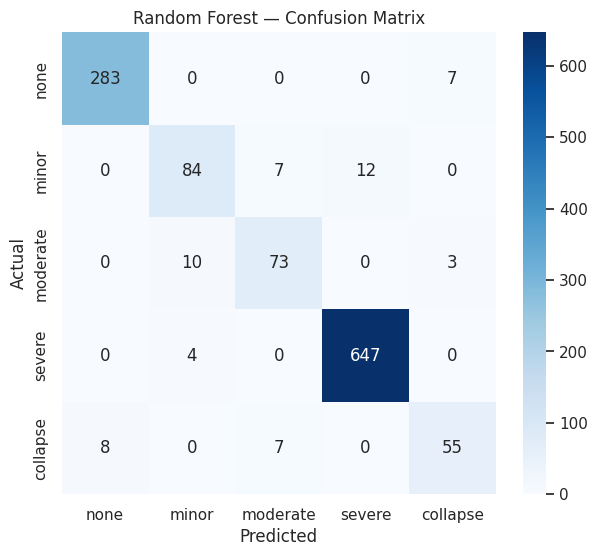

In [5]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=damage_order, yticklabels=damage_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

/tmp/ipykernel_595/55077076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="rocket")


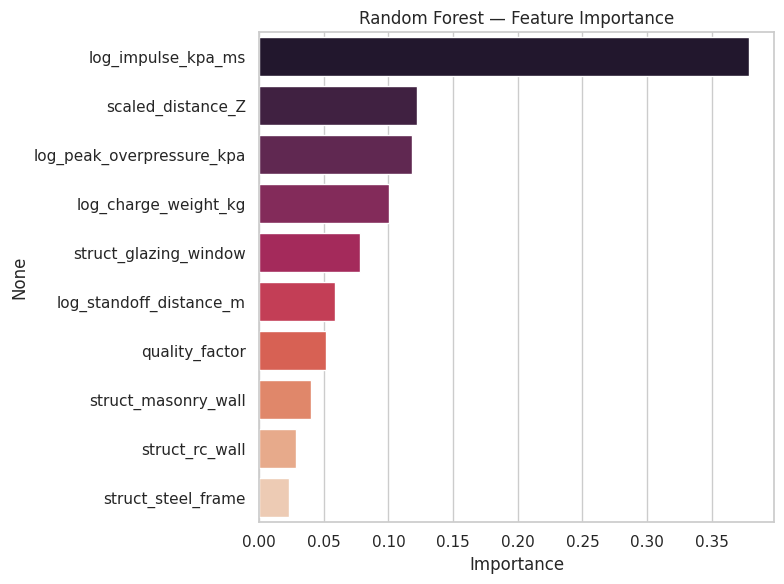

In [6]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="rocket")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Sanity check:** `scaled_distance_Z` and the log-transformed overpressure /
impulse features should dominate feature importance, since they're the
direct physical drivers of damage in the P-I curve logic. If `quality_factor`
or a `struct_*` dummy ranks above these, that's worth investigating.

## 4. Model 2 — XGBoost

In [7]:
# Compute sample weights to address class imbalance (XGBoost has no
# built-in class_weight="balanced" for multiclass, so we do it manually)
class_counts = pd.Series(y_train).value_counts()
class_weights = {cls: len(y_train) / (len(class_counts) * count)
                 for cls, count in class_counts.items()}
sample_weights = np.array([class_weights[label] for label in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(damage_order),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

xgb_preds = xgb_model.predict(X_test)
print("XGBoost accuracy:", accuracy_score(y_test, xgb_preds))
print("XGBoost macro-F1:", f1_score(y_test, xgb_preds, average="macro"))
print()
print(classification_report(y_test, xgb_preds, target_names=damage_order))

XGBoost accuracy: 0.96
XGBoost macro-F1: 0.91451222904943

              precision    recall  f1-score   support

        none       0.99      0.97      0.98       290
       minor       0.86      0.90      0.88       103
    moderate       0.88      0.91      0.89        86
      severe       0.99      0.99      0.99       651
    collapse       0.84      0.83      0.83        70

    accuracy                           0.96      1200
   macro avg       0.91      0.92      0.91      1200
weighted avg       0.96      0.96      0.96      1200



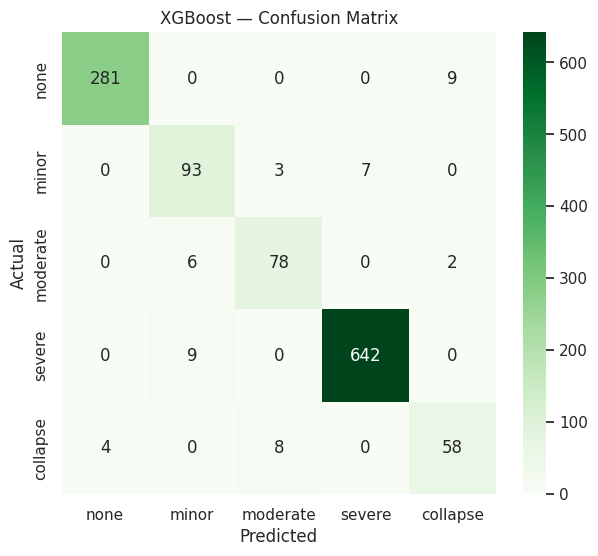

In [8]:
cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=damage_order, yticklabels=damage_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost — Confusion Matrix")
plt.show()

## 5. Model 3 — Small Neural Network (MLPClassifier)

Neural nets need scaled input features, so we standardize first. This is
a quick sklearn MLP for comparison — if you want PyTorch fluency for your
portfolio (recommended given your PFN/research-lab target), the next step
is porting this exact architecture (2 hidden layers, ReLU) into a
`torch.nn.Module` with a manual training loop, which is a natural v2 of this
notebook.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp.fit(X_train_scaled, y_train)

mlp_preds = mlp.predict(X_test_scaled)
print("MLP accuracy:", accuracy_score(y_test, mlp_preds))
print("MLP macro-F1:", f1_score(y_test, mlp_preds, average="macro"))
print()
print(classification_report(y_test, mlp_preds, target_names=damage_order))

MLP accuracy: 0.9733333333333334
MLP macro-F1: 0.9397369579631759

              precision    recall  f1-score   support

        none       0.98      0.99      0.99       290
       minor       0.96      0.89      0.92       103
    moderate       0.91      0.93      0.92        86
      severe       0.99      1.00      0.99       651
    collapse       0.90      0.86      0.88        70

    accuracy                           0.97      1200
   macro avg       0.95      0.93      0.94      1200
weighted avg       0.97      0.97      0.97      1200



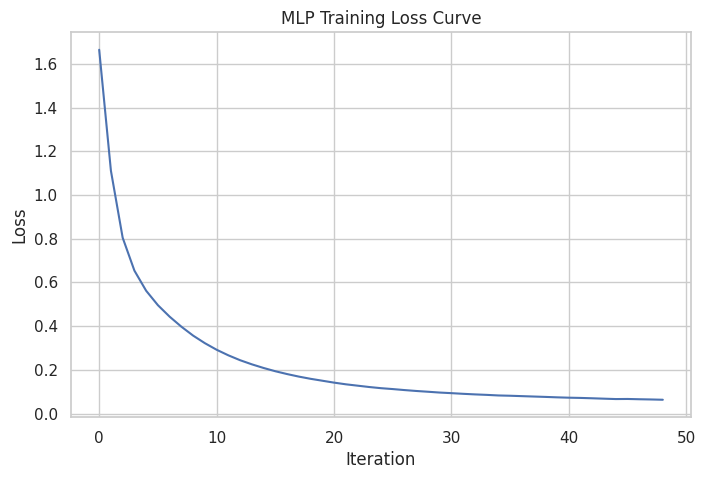

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## 6. Model comparison summary

In [11]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP (sklearn)"],
    "Accuracy": [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, mlp_preds),
    ],
    "Macro F1": [
        f1_score(y_test, rf_preds, average="macro"),
        f1_score(y_test, xgb_preds, average="macro"),
        f1_score(y_test, mlp_preds, average="macro"),
    ],
})
results

,Model,Accuracy,Macro F1
0,Random Forest,0.951667,0.891307
1,XGBoost,0.960000,0.914512
2,MLP (sklearn),0.973333,0.939737


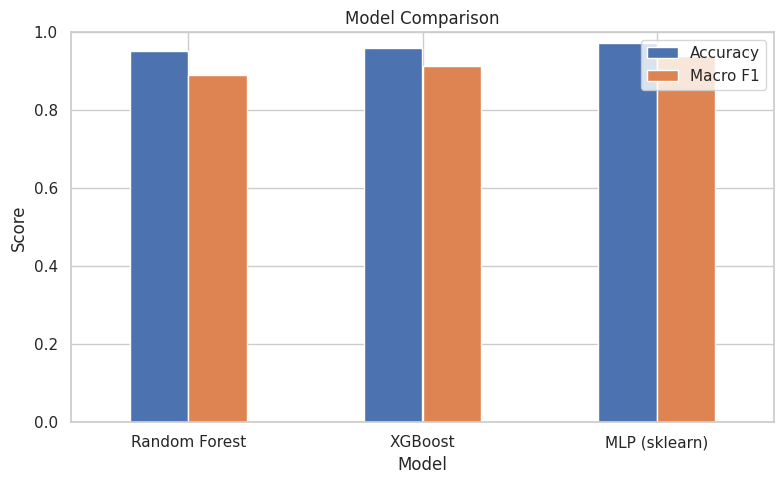

In [12]:
results.set_index("Model")[["Accuracy", "Macro F1"]].plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Discussion & next steps

- **Macro F1** (not accuracy) is the fairer comparison metric here, since
  accuracy is inflated by the dominant `none`/`collapse` classes
- If Random Forest and XGBoost both significantly outperform the MLP, that's
  a completely normal and expected result on small-to-medium tabular
  datasets — worth explicitly saying so in a report/interview rather than
  treating it as a failure of the neural net
- **Possible next steps:**
  1. Hyperparameter tuning (GridSearchCV / Optuna) on the best-performing
     model
  2. Try `SMOTE` or other oversampling for the minority classes
     (minor/moderate/severe) instead of just class weighting
  3. Port the MLP into PyTorch with a custom training loop — good for
     demonstrating deep learning framework fluency for research-lab
     applications
  4. Validate against any real published blast-test data points you can
     find, since this entire dataset is currently synthetic
  5. Wrap the best model in a small Flask/FastAPI endpoint and deploy it
     alongside HazardScope as a second demo tool
